In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import json
import matplotlib.pyplot as plt
import time
import os

# ==========================================
# 1. 准备全局数据 (只下载一次，后续复用)
# ==========================================
print("正在准备 CIFAR-100 数据集...")
BATCH_SIZE = 64
NUM_CLASSES = 100
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print("数据集准备完毕！")

# ==========================================
# 2. 定义一键实验函数 (封装所有逻辑)
# ==========================================
def run_experiment(model_name, train_mode):
    exp_name = f"{model_name}_{train_mode}_final"
    print(f"\n========== 开始实验: {exp_name} ==========")
    
    # 动态设定轮数和学习率
    num_epochs = 30 if train_mode == 'scratch' else 20
    lr = 0.01 if train_mode == 'scratch' else 1e-4

    # 构建模型
    if model_name == 'resnext':
        model = models.resnext50_32x4d(weights=None if train_mode == 'scratch' else models.ResNeXt50_32X4D_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    elif model_name == 'densenet':
        model = models.densenet121(weights=None if train_mode == 'scratch' else models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'test_acc': []}
    start_time = time.time()

    # 训练与测试循环
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            optimizer.zero_grad() 
            outputs = model(inputs) 
            loss = criterion(outputs, labels) 
            loss.backward() 
            optimizer.step() 
            running_loss += loss.item()
                
        avg_train_loss = running_loss / len(trainloader)
        history['train_loss'].append(avg_train_loss)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data in testloader:
                inputs, labels = data[0].to(device), data[1].to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_acc = 100 * correct / total
        history['test_acc'].append(test_acc)
        print(f'[Epoch {epoch+1}/{num_epochs}] Loss: {avg_train_loss:.3f} | Test Acc: {test_acc:.2f}%')

    end_time = time.time()
    print(f"\n✅ 实验完成! 耗时: {(end_time - start_time)/60:.2f} 分钟")

    # ==========================================
    # 极简保存逻辑：直接保存在当前目录
    # ==========================================
    json_path = f'{exp_name}_history.json'
    plot_path = f'{exp_name}_plot.png'

    with open(json_path, 'w') as f:
        json.dump(history, f)

    # 画图并直接在网页中显示出来
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o', markersize=3)
    plt.title(f'{exp_name} - Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['test_acc'], label='Test Acc (%)', color='orange', marker='x', markersize=3)
    plt.title(f'{exp_name} - Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.savefig(plot_path, dpi=300)
    print(f"数据和图表已保存至当前目录: {json_path} 和 {plot_path}")
    
    plt.show()

正在准备 CIFAR-100 数据集...
当前使用的计算设备: cuda:0


100%|██████████| 169M/169M [00:02<00:00, 71.5MB/s] 


数据集准备完毕！



========== 开始实验: resnext_scratch_final ==========
[Epoch 1/30] Loss: 4.965 | Test Acc: 6.10%
[Epoch 2/30] Loss: 3.923 | Test Acc: 11.20%
[Epoch 3/30] Loss: 3.588 | Test Acc: 9.22%
[Epoch 4/30] Loss: 3.378 | Test Acc: 18.87%
[Epoch 5/30] Loss: 3.264 | Test Acc: 19.58%
[Epoch 6/30] Loss: 3.515 | Test Acc: 16.91%
[Epoch 7/30] Loss: 3.333 | Test Acc: 23.27%
[Epoch 8/30] Loss: 3.111 | Test Acc: 26.21%
[Epoch 9/30] Loss: 3.108 | Test Acc: 25.26%
[Epoch 10/30] Loss: 2.959 | Test Acc: 28.56%
[Epoch 11/30] Loss: 2.934 | Test Acc: 27.95%
[Epoch 12/30] Loss: 2.780 | Test Acc: 29.98%
[Epoch 13/30] Loss: 2.843 | Test Acc: 29.24%
[Epoch 14/30] Loss: 2.717 | Test Acc: 29.10%
[Epoch 15/30] Loss: 2.711 | Test Acc: 18.23%
[Epoch 16/30] Loss: 2.858 | Test Acc: 31.17%
[Epoch 17/30] Loss: 2.549 | Test Acc: 35.88%
[Epoch 18/30] Loss: 2.498 | Test Acc: 35.31%
[Epoch 19/30] Loss: 2.332 | Test Acc: 31.58%
[Epoch 20/30] Loss: 2.335 | Test Acc: 34.89%
[Epoch 21/30] Loss: 2.266 | Test Acc: 36.21%
[Epoch 22/30] L

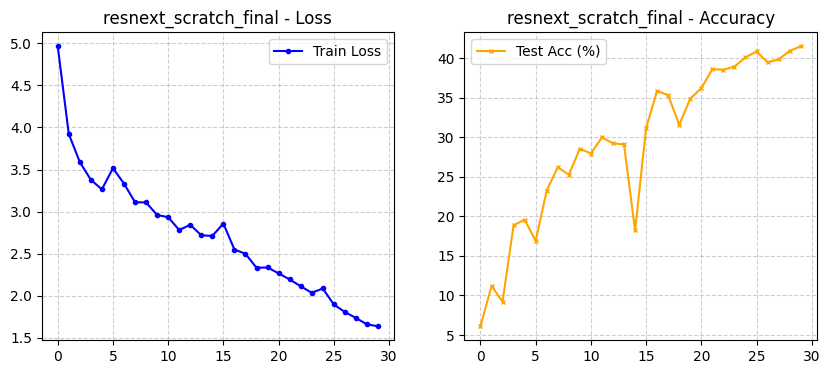

In [3]:
run_experiment(model_name='resnext', train_mode='scratch')


========== 开始实验: resnext_full_finetune_final ==========
Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 168MB/s] 


[Epoch 1/20] Loss: 3.263 | Test Acc: 43.63%
[Epoch 2/20] Loss: 1.892 | Test Acc: 54.25%
[Epoch 3/20] Loss: 1.428 | Test Acc: 58.49%
[Epoch 4/20] Loss: 1.138 | Test Acc: 60.43%
[Epoch 5/20] Loss: 0.919 | Test Acc: 61.33%
[Epoch 6/20] Loss: 0.753 | Test Acc: 62.55%
[Epoch 7/20] Loss: 0.621 | Test Acc: 62.74%
[Epoch 8/20] Loss: 0.520 | Test Acc: 63.57%
[Epoch 9/20] Loss: 0.432 | Test Acc: 63.13%
[Epoch 10/20] Loss: 0.376 | Test Acc: 63.69%
[Epoch 11/20] Loss: 0.328 | Test Acc: 63.57%
[Epoch 12/20] Loss: 0.293 | Test Acc: 64.33%
[Epoch 13/20] Loss: 0.268 | Test Acc: 64.16%
[Epoch 14/20] Loss: 0.247 | Test Acc: 63.96%
[Epoch 15/20] Loss: 0.224 | Test Acc: 64.18%
[Epoch 16/20] Loss: 0.187 | Test Acc: 64.33%
[Epoch 17/20] Loss: 0.182 | Test Acc: 65.05%
[Epoch 18/20] Loss: 0.153 | Test Acc: 64.85%
[Epoch 19/20] Loss: 0.150 | Test Acc: 63.90%
[Epoch 20/20] Loss: 0.135 | Test Acc: 64.32%

✅ 实验完成! 耗时: 19.37 分钟
数据和图表已保存至当前目录: resnext_full_finetune_final_history.json 和 resnext_full_finetune_final_p

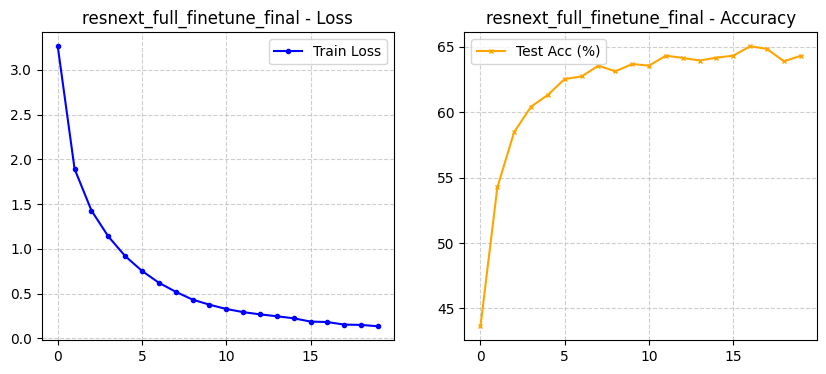

In [4]:
run_experiment(model_name='resnext', train_mode='full_finetune')

In [ ]:
run_experiment(model_name='densenet', train_mode='scratch')


========== 开始实验: densenet_full_finetune_final ==========
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 155MB/s] 


[Epoch 1/20] Loss: 2.966 | Test Acc: 49.27%
[Epoch 2/20] Loss: 1.692 | Test Acc: 57.21%
[Epoch 3/20] Loss: 1.303 | Test Acc: 60.83%
[Epoch 4/20] Loss: 1.045 | Test Acc: 61.75%
[Epoch 5/20] Loss: 0.856 | Test Acc: 62.94%
[Epoch 6/20] Loss: 0.686 | Test Acc: 63.95%
[Epoch 7/20] Loss: 0.553 | Test Acc: 62.90%
[Epoch 8/20] Loss: 0.459 | Test Acc: 63.80%
[Epoch 9/20] Loss: 0.362 | Test Acc: 64.25%
[Epoch 10/20] Loss: 0.307 | Test Acc: 63.79%
[Epoch 11/20] Loss: 0.253 | Test Acc: 63.57%
[Epoch 12/20] Loss: 0.220 | Test Acc: 64.34%
[Epoch 13/20] Loss: 0.192 | Test Acc: 64.00%
[Epoch 14/20] Loss: 0.177 | Test Acc: 64.15%
[Epoch 15/20] Loss: 0.169 | Test Acc: 64.14%
[Epoch 16/20] Loss: 0.151 | Test Acc: 63.23%
[Epoch 17/20] Loss: 0.144 | Test Acc: 63.48%
[Epoch 18/20] Loss: 0.133 | Test Acc: 64.14%
[Epoch 19/20] Loss: 0.121 | Test Acc: 63.71%
[Epoch 20/20] Loss: 0.121 | Test Acc: 64.27%

✅ 实验完成! 耗时: 18.96 分钟
数据和图表已保存至当前目录: densenet_full_finetune_final_history.json 和 densenet_full_finetune_final

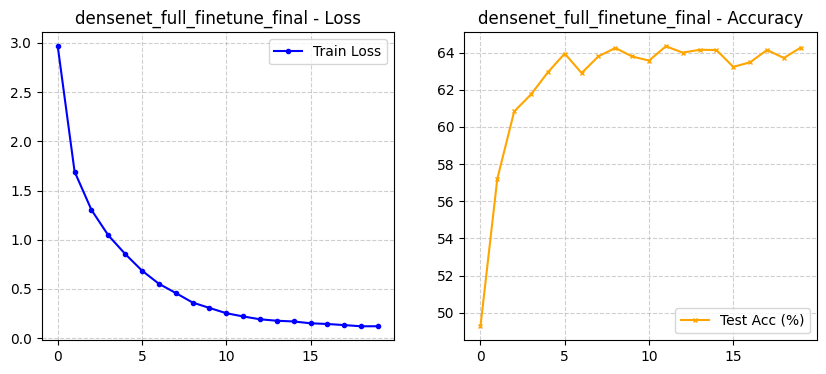

In [2]:
run_experiment(model_name='densenet', train_mode='full_finetune')